Plotting Time-Series grid for all files...


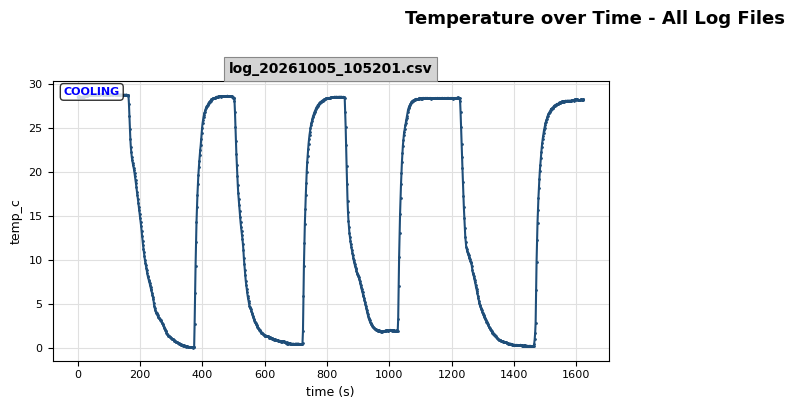


Plot saved as 'temp_vs_time_response.png'
Total files plotted: 1


In [14]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of CSV files from your git repository
csv_files = [
    "log_20261005_105201.csv",
]

# If files are in a data folder, uncomment this:
folder_path = "../../data"
csv_files = [os.path.join(folder_path, f) for f in csv_files]

def plot_time_series_grid(file_list, n_cols=2):
    """
    Plot temp_c vs time for each file in a grid layout
    """
    n_files = len(file_list)
    if n_files == 0:
        print("No files to plot")
        return
    
    n_rows = math.ceil(n_files / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, file_path in enumerate(file_list):
        ax = axes_flat[idx]
        file_name = os.path.basename(file_path)
        
        # Read CSV file
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        # Check if required columns exist
        if 'temp_c' not in df.columns:
            print(f"Warning: 'temp_c' column not found in {file_name}")
            ax.set_title(file_name, fontsize=10, fontweight='bold',
                        pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                        facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
            ax.text(0.5, 0.5, 'No temp_c column', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Plot temp_c vs time
        if 'time_ms' in df.columns:
            # Convert milliseconds to seconds
            t_sec = df['time_ms'] / 1000.0
            ax.plot(t_sec, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time (s)", fontsize=9)
        elif 'time' in df.columns:
            ax.plot(df['time'], df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time", fontsize=9)
        else:
            # Use index as time
            ax.plot(df.index, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("sample", fontsize=9)
        
        ax.set_ylabel("temp_c", fontsize=9)
        ax.set_title(file_name, fontsize=10, fontweight='bold',
                    pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                    facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
        
        # Add grid
        ax.grid(True, color="#e0e0e0", linestyle="-", linewidth=0.8)
        ax.tick_params(labelsize=8)
        
        # Determine if heating or cooling based on trend
        if len(df) > 10:
            # Compare first 10% and last 10% of data
            n_samples = len(df)
            first_avg = df['temp_c'].iloc[:n_samples//10].mean()
            last_avg = df['temp_c'].iloc[-n_samples//10:].mean()
            
            if last_avg > first_avg + 1:
                trend = "HEATING"
                color = "red"
            elif last_avg < first_avg - 1:
                trend = "COOLING"
                color = "blue"
            else:
                trend = "STABLE"
                color = "green"
            
            ax.text(0.02, 0.98, trend, transform=ax.transAxes, fontsize=8, 
                   fontweight='bold', color=color, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Hide unused subplots
    for j in range(n_files, len(axes_flat)):
        fig.delaxes(axes_flat[j])
    
    fig.suptitle("Temperature over Time - All Log Files", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("temp_vs_time_response.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 'temp_vs_time_response.png'")
    print(f"Total files plotted: {n_files}")

# Run the plot
print("Plotting Time-Series grid for all files...")
plot_time_series_grid(csv_files, n_cols=2)

In [15]:
raw_response_df.head(3)  # Display first 3 rows of heating data

,time_ms,temp_c,temp_k,adc,source
0,587,28.50,301.65,281,log_20261005_105201.csv
1,2093,28.50,301.65,280,log_20261005_105201.csv
2,3598,28.56,301.71,280,log_20261005_105201.csv


In [16]:
raw_response_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time_ms  1079 non-null   int64  
 1   temp_c   1079 non-null   float64
 2   temp_k   1079 non-null   float64
 3   adc      1079 non-null   int64  
 4   source   1079 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 42.3+ KB


In [17]:
import matplotlib.pyplot as plt

def plot_adc_vs_temp(x, y, title="ADC vs Temperature", x_label="ADC Value", y_label="Temperature (°C)", color='blue', alpha=0.5):
    """
    Plots ADC values against Temperature (°C).
    
    Parameters:
    - x: array-like, ADC values (e.g., df['adc'])
    - y: array-like, Temperature values in Celsius (e.g., df['temp_c'])
    - title: str, title of the plot
    - x_label: str, label for the x-axis
    - y_label: str, label for the y-axis
    - color: str, color of the scatter points
    - alpha: float, transparency of the scatter points (0.0 to 1.0)
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color=color, alpha=0.6, s=15, edgecolors='none')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

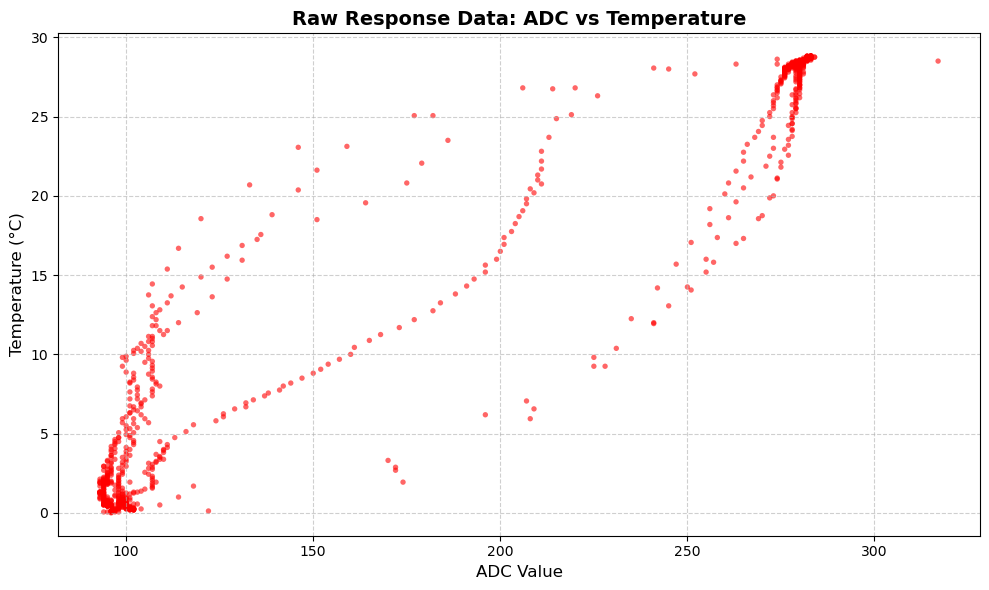

In [18]:
# 1. Plot Raw Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=raw_response_df['adc'], 
    y=raw_response_df['temp_c'], 
    title="Raw Response Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

In [19]:
# ------------------------------------------------------------
# 1. Find the sharp rises (ice -> room-temp beaker) from the thermistor ADC
# ------------------------------------------------------------
d = raw_response_df.dropna(subset=['adc']).reset_index(drop=True)
t_s = d['time_ms'] / 1000.0
adc = d['adc'].astype(float)

K = 3                                    # look K samples ahead (~4-5 s)
THRESH = 0.3 * (adc.max() - adc.min())   # a rise = ADC climbs > 30% of its full span within K samples
MIN_RUN = 2                              # ignore single-sample noise spikes

jump = ((adc.shift(-K) - adc) > THRESH).fillna(False).values

starts, run = [], 0
for i, flag in enumerate(jump):
    if flag:
        run += 1
        if run == MIN_RUN:
            starts.append(i - MIN_RUN + 1)   # first sample of the rise
    else:
        run = 0

print(f"Found {len(starts)} sharp rises at t = {[round(t_s[i]) for i in starts]} s")

Found 4 sharp rises at t = [371, 719, 1024, 1467] s


In [20]:
# ------------------------------------------------------------
# 2. Cut at every rise -> pieces (each starts at the last cold sample before the jump)
# ------------------------------------------------------------
cuts = [0] + starts + [len(d)]
pieces = []
for a, b in zip(cuts[:-1], cuts[1:]):
    p = d.iloc[a:b].copy()
    p['t_rel_s'] = (p['time_ms'] - p['time_ms'].iloc[0]) / 1000.0   # time restarts at 0 in each piece
    pieces.append(p)
print(f"{len(pieces)} pieces, rows per piece: {[len(p) for p in pieces]}")

5 pieces, rows per piece: [246, 231, 203, 294, 105]


In [21]:
# ------------------------------------------------------------
# 3. Keep only the middle pieces (drop the first and last, which are incomplete)
# ------------------------------------------------------------
middle = pieces[1:-1]
if len(middle) == 3:
    raw_response_1_df, raw_response_2_df, raw_response_3_df = middle
else:
    print(f"WARNING: expected 3 middle pieces, got {len(middle)}. Adjust K / THRESH / MIN_RUN.")

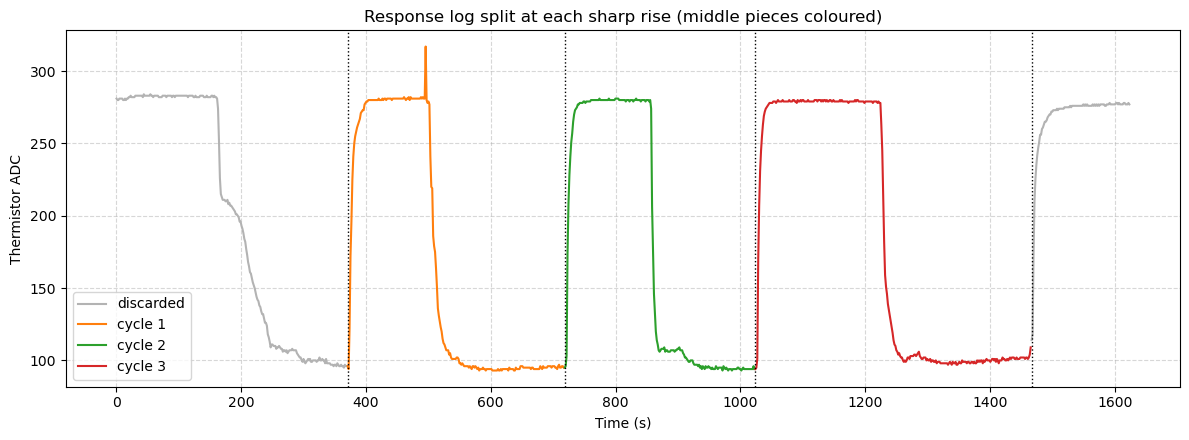

In [22]:
# ------------------------------------------------------------
# 4. Check the cuts visually
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4.5))
for idx, p in enumerate(pieces):
    is_end = idx in (0, len(pieces) - 1)
    ax.plot(p['time_ms'] / 1000, p['adc'], color='0.7' if is_end else f'C{idx}', lw=1.5,
            label='discarded' if is_end and idx == 0 else (None if is_end else f'cycle {idx}'))
for i in starts:
    ax.axvline(t_s[i], color='black', linestyle=':', lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Thermistor ADC")
ax.set_title("Response log split at each sharp rise (middle pieces coloured)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()